In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dtreeviz

plt.style.use('ggplot')

In [24]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Model

In [7]:
data = load_diabetes()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(data.data,data.target,train_size=.7)

In [34]:
clf = DecisionTreeRegressor(criterion = 'squared_error',
                             max_depth = 8,
                             min_samples_leaf =  39,
                             min_samples_split = 36,
                             splitter = 'random')
clf.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=39, min_samples_split=36,
                      splitter='random')

In [35]:
y_pred = clf.predict(X_test)
r2_score(y_pred=y_pred,y_true=y_test)

0.31697579985478586

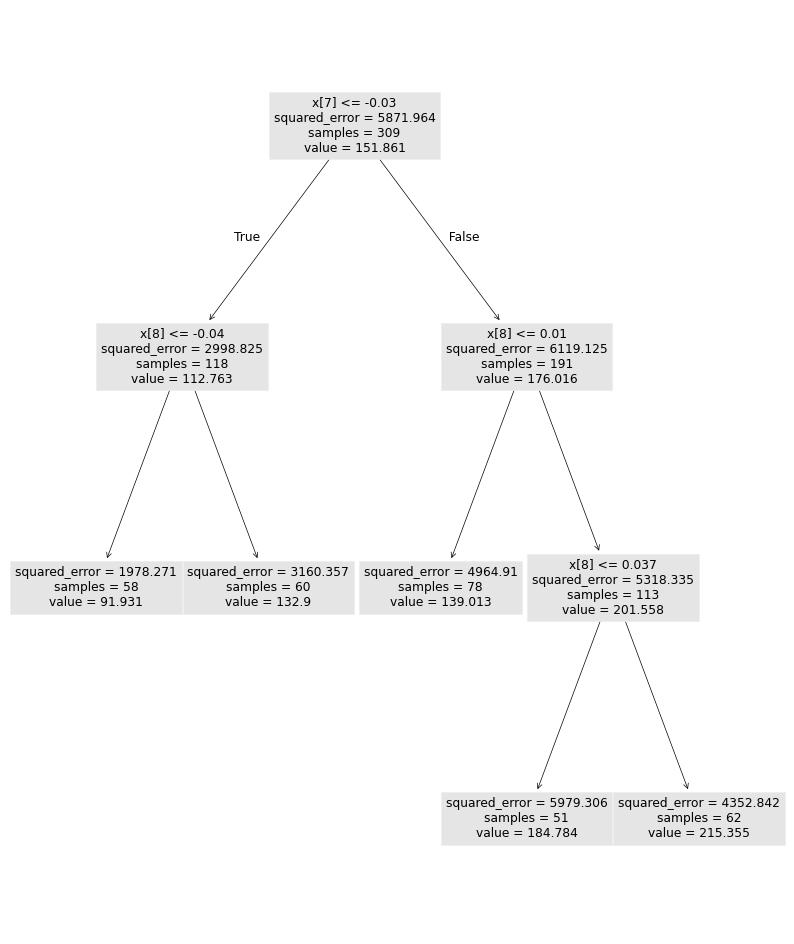

In [36]:
plt.figure(figsize=(10,12))
plot_tree(clf)
plt.show()

# Graphical Visualization

In [42]:
viz_model = dtreeviz.model(clf,
                           X_train=X_train,
                           y_train=y_train,
                           feature_names=data.feature_names,
                           target_name='diabetes',
                           )

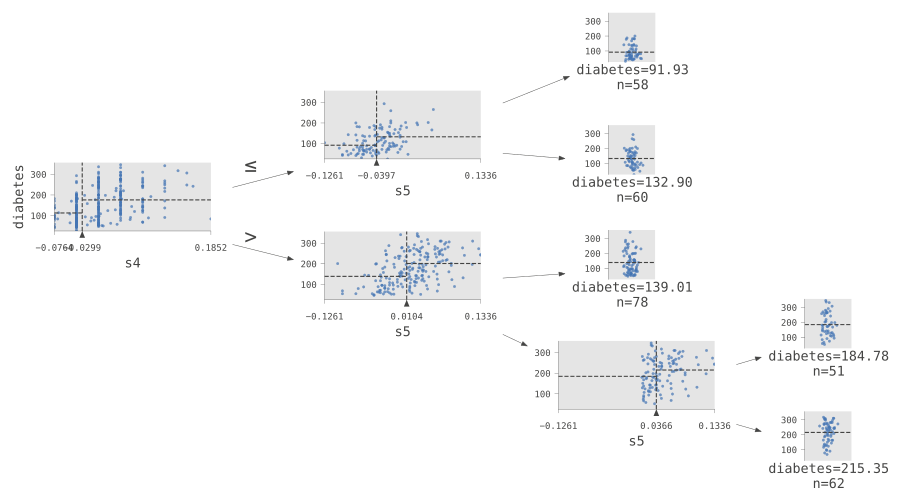

In [45]:
viz_model.view(scale=1.5,
               fontname='monospace',
               orientation='LR'
              )

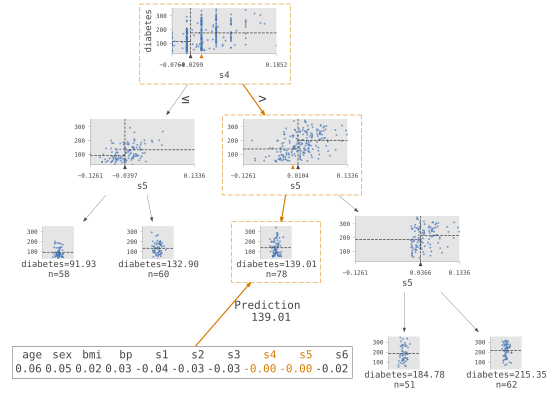

In [44]:
viz_model.view(scale=1,
               fontname='monospace',
               x=data.data[51]
              )

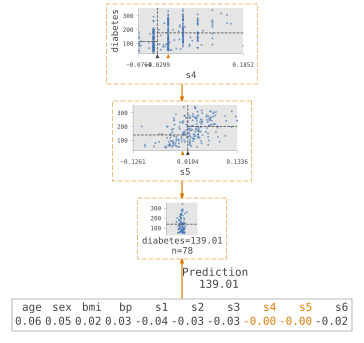

In [46]:
viz_model.view(x=data.data[51],
               show_just_path=True,
               fontname='monospace'
              )

In [47]:
print(viz_model.explain_prediction_path(data.data[51]))

-0.03 <= s4 
s5 < 0.01



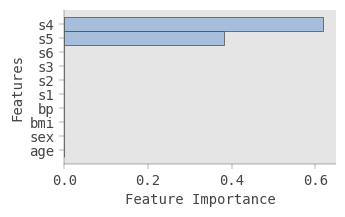

In [48]:
viz_model.instance_feature_importance(data.data[51], figsize=(3.5,2),
               fontname='monospace')

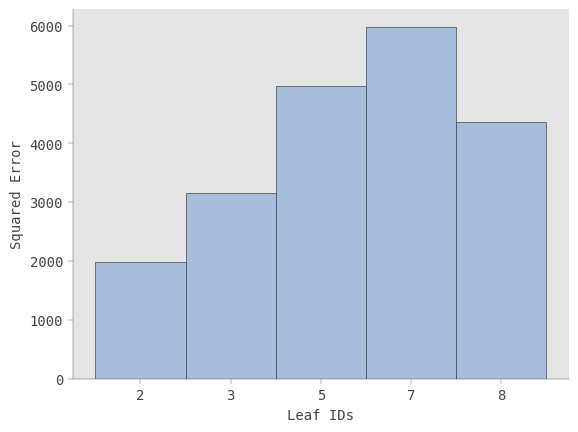

In [49]:
viz_model.leaf_purity(fontname='monospace')

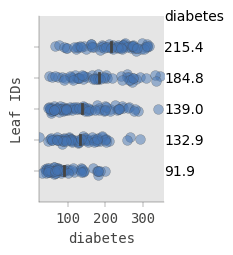

In [50]:
viz_model.rtree_leaf_distributions(fontname='monospace')

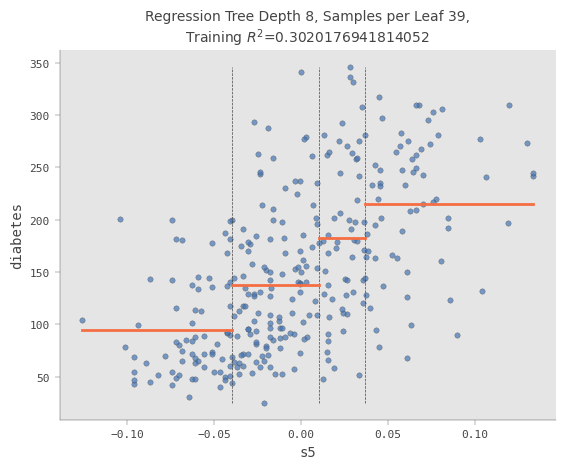

In [54]:
viz_model.rtree_feature_space(features=['s5'],fontname='monospace')

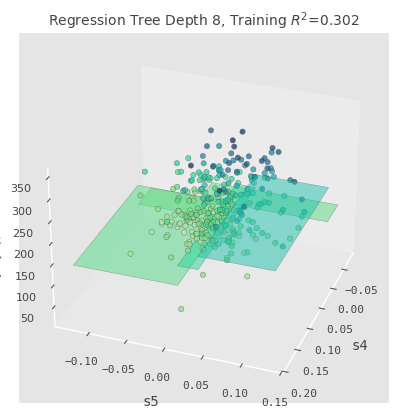

In [57]:
viz_model.rtree_feature_space3D(features=['s4','s5'],
                                 fontsize=10,
                                 fontname='monospace',
                                 elev=30, azim=20,
                                 show={'splits', 'title'},
                                 colors={'tessellation_alpha': .5})

# Hyperparameter Tuning

In [32]:
from time import time
pl = Pipeline([
    ('cls', DecisionTreeRegressor())
])

max_depth = [i for i in range(1,11)]
max_depth.append(None)
param_grid={
    'cls__criterion' : ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    'cls__splitter' : ["best", "random"],
    'cls__max_depth' : max_depth,
    'cls__min_samples_split': [i for i in range(30,41)],
    'cls__min_samples_leaf': [i for i in range(30,41)],
    # 'cls__max_features': [i for i in range(1,X.shape[1])],
}
gscv = GridSearchCV(pl, param_grid=param_grid,cv=5)
now = time()
gscv.fit(data.data,data.target)
time() - now

107.87429738044739

In [33]:
gscv.best_params_

{'cls__criterion': 'squared_error',
 'cls__max_depth': 8,
 'cls__min_samples_leaf': 39,
 'cls__min_samples_split': 36,
 'cls__splitter': 'random'}

In [19]:
data.data.shape

(442, 10)

# Feature Importance

In [37]:
for importance, name in sorted(zip(clf.feature_importances_,data.feature_names), reverse=True):
    print(name, importance)

s4 0.5325308813067324
s5 0.4674691186932676
sex 0.0
s6 0.0
s3 0.0
s2 0.0
s1 0.0
bp 0.0
bmi 0.0
age 0.0
